In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [47]:
df = pd.read_csv('../data/processed/feature_engineered_shots.csv')
df.head()

,minute,second,period,under_pressure,shot_first_time,shot_one_on_one,shot_open_goal,shot_deflected,x,y,...,shot_technique_Volley,play_pattern_From Counter,play_pattern_From Free Kick,play_pattern_From Goal Kick,play_pattern_From Keeper,play_pattern_From Kick Off,play_pattern_From Throw In,play_pattern_Other,play_pattern_Regular Play,shot_distance
0,3,36,1,1,0,0,0,0,106.7,42.1,...,0,0,1,0,0,0,0,0,0,13.464769
1,6,10,1,0,1,0,0,0,109.1,35.5,...,0,0,0,0,0,0,0,0,0,11.792370
2,7,8,1,0,0,0,0,0,113.6,23.8,...,0,0,0,0,0,0,0,0,1,17.418381
3,13,4,1,0,0,0,0,0,91.8,40.2,...,0,0,0,0,0,0,0,0,0,28.200709
4,20,1,1,0,0,0,0,0,111.0,31.3,...,0,0,0,0,0,0,0,0,0,12.517588


In [48]:
X = df.drop(
    columns=[
        "goal",
        "end_x",
        "end_y"
    ]
)

y = df["goal"]

In [49]:
X_train,X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [51]:
rf_pred=rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [52]:
print("Accuracy")
print(accuracy_score(y_test, rf_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test,rf_prob))

print('\nClassification report:')
print(classification_report(y_test,rf_pred))

Accuracy
0.8436109345200254

ROC-AUC:
0.7809961866572316

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1390
           1       0.36      0.45      0.40       183

    accuracy                           0.84      1573
   macro avg       0.64      0.67      0.66      1573
weighted avg       0.86      0.84      0.85      1573



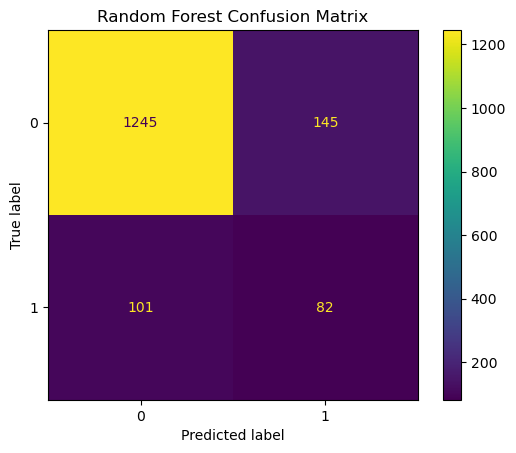

In [53]:


cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="viridis")

plt.title("Random Forest Confusion Matrix")

plt.show()

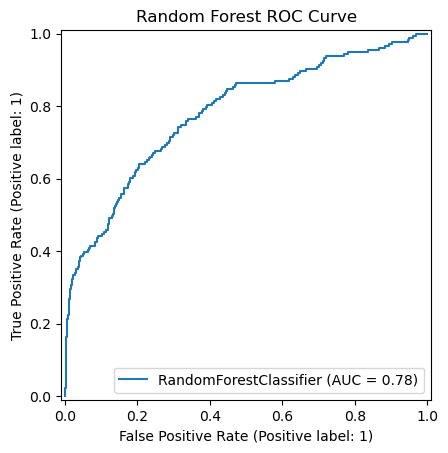

In [54]:


RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")

plt.show()

In [55]:
#gradient boosting `
 
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [56]:
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(
    X_test
)[:,1]

In [57]:
print("Accuracy:")
print(accuracy_score(y_test, gb_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, gb_prob))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Accuracy:
0.9046408137317228

ROC-AUC:
0.8101368085859182

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1390
           1       0.70      0.31      0.43       183

    accuracy                           0.90      1573
   macro avg       0.81      0.65      0.69      1573
weighted avg       0.89      0.90      0.89      1573



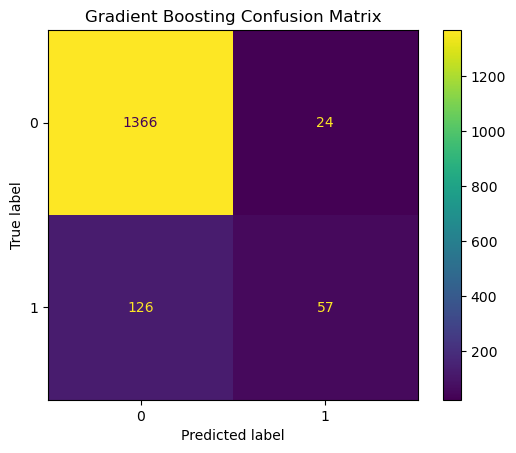

In [58]:
cm = confusion_matrix(
    y_test,
    gb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="viridis")

plt.title("Gradient Boosting Confusion Matrix")

plt.show()

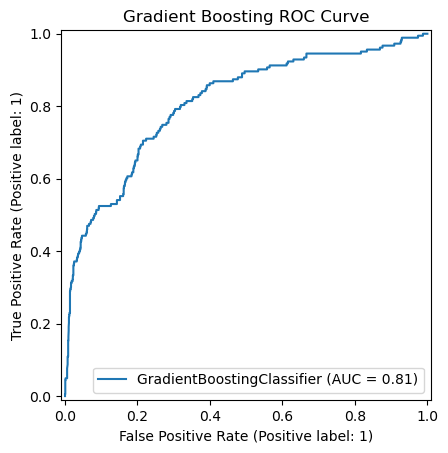

In [59]:
RocCurveDisplay.from_estimator(
    gb_model,
    X_test,
    y_test
)

plt.title("Gradient Boosting ROC Curve")

plt.show()

In [60]:
#xgboost model

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=7,  #as goals are minority class
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [61]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [62]:
print("Accuracy:")
print(accuracy_score(y_test, xgb_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, xgb_prob))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy:
0.8277177368086459

ROC-AUC:
0.7992216063215002

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1390
           1       0.35      0.57      0.44       183

    accuracy                           0.83      1573
   macro avg       0.65      0.72      0.67      1573
weighted avg       0.87      0.83      0.84      1573



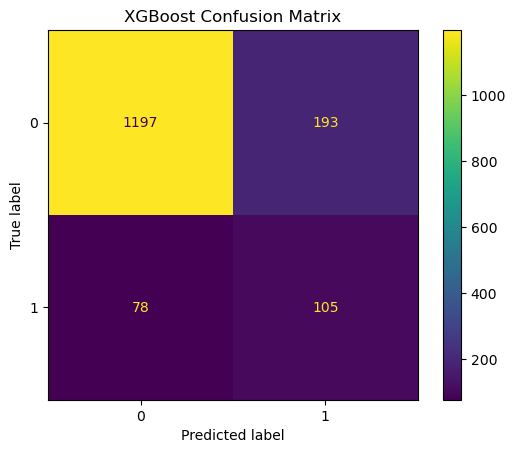

In [63]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="viridis")

plt.title("XGBoost Confusion Matrix")

plt.show()

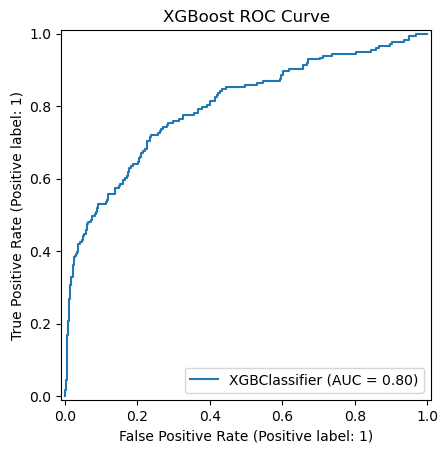

In [64]:
RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("XGBoost ROC Curve")

plt.show()

In [65]:
# feature importance for xgboost
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(15))

                       feature  importance
27          play_pattern_Other    0.168080
10                  shot_angle    0.092597
3               under_pressure    0.055416
29               shot_distance    0.048772
5              shot_one_on_one    0.045085
14   shot_body_part_Right Foot    0.036495
7               shot_deflected    0.035117
12    shot_body_part_Left Foot    0.034210
17          shot_technique_Lob    0.030914
21   play_pattern_From Counter    0.030459
6               shot_open_goal    0.028889
18       shot_technique_Normal    0.027307
8                            x    0.026458
11        distance_from_center    0.025554
16  shot_technique_Half Volley    0.025177


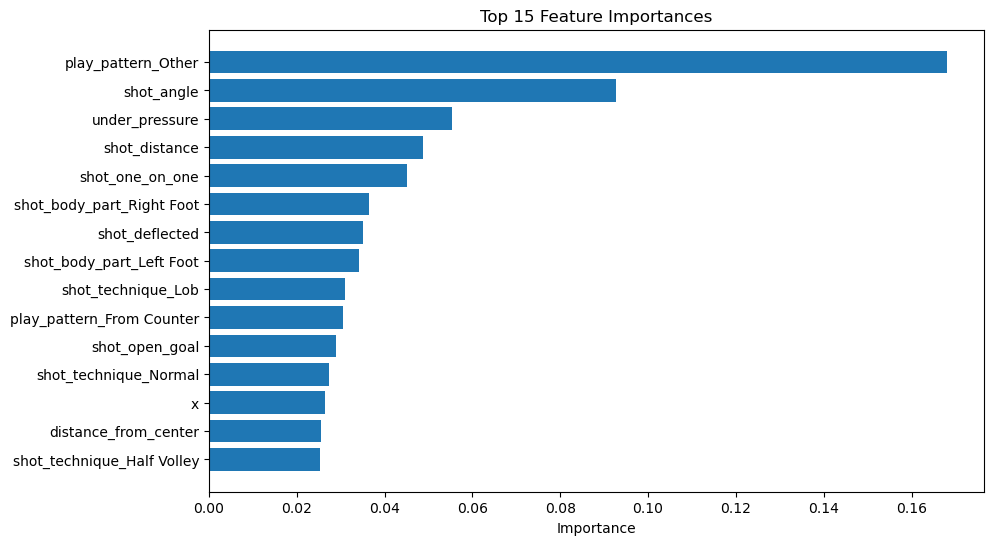

In [66]:


top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances")

plt.xlabel("Importance")

plt.show()

In [71]:
#logistic regression model has been selected because of the highest roc-auc (0.82) and highest recall (0.68)
# now we optimise the model



In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# target and features
X = df.drop(columns=["goal"])
y = df["goal"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [73]:
lr = LogisticRegression(
    max_iter=1000
)
param_grid={
    "C":[0.01,0.1,1,10,100], #regularization strength
    'solver':['liblinear','lbfgs'], #optimization algorithm
    'class_weight':[None,'balanced'] #imbalance handling
}


In [74]:
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    verbose=1,
    n_jobs=-1
)

grid_search.fit(
    X_train_scaled,
    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc', verbose=1)

In [75]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest ROC-AUC Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 100, 'class_weight': None, 'solver': 'liblinear'}

Best ROC-AUC Score:
0.9260341588017085


In [76]:
#final model
best_log_model = grid_search.best_estimator_

best_log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(C=100, max_iter=1000, solver='liblinear')

In [77]:
y_pred = best_log_model.predict(X_test_scaled)

y_prob = best_log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [78]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.926255562619199

ROC-AUC:
0.9243110429689035

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1390
           1       0.80      0.49      0.61       183

    accuracy                           0.93      1573
   macro avg       0.87      0.74      0.78      1573
weighted avg       0.92      0.93      0.92      1573



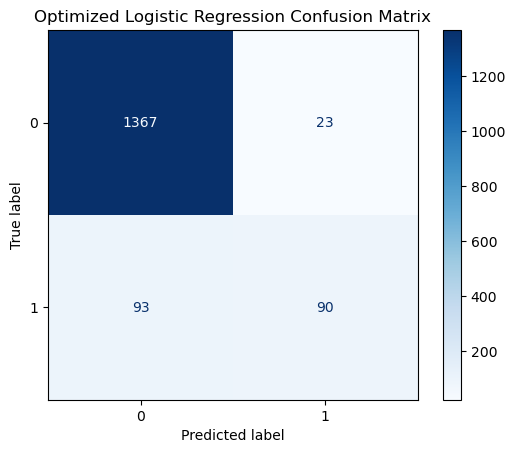

In [79]:
ConfusionMatrixDisplay.from_estimator(
    best_log_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Optimized Logistic Regression Confusion Matrix")
plt.show()

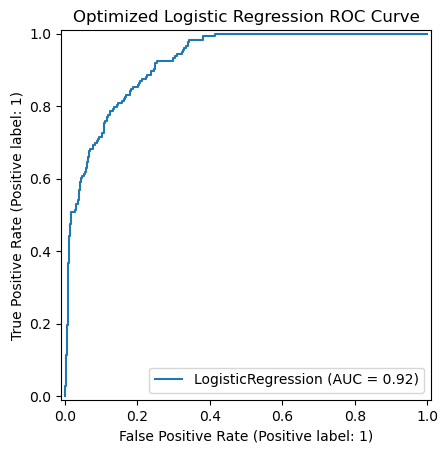

In [80]:
RocCurveDisplay.from_estimator(
    best_log_model,
    X_test_scaled,
    y_test
)

plt.title("Optimized Logistic Regression ROC Curve")
plt.show()

In [81]:
import joblib

joblib.dump(
    best_log_model,
    "../models/optimized_logistic_regression.pkl"
)

['../models/optimized_logistic_regression.pkl']

In [82]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [83]:
joblib.dump(
    X.columns.tolist(),
    "../models/feature_columns.pkl"
)

['../models/feature_columns.pkl']